In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("HR_Attrition.csv")   

# Display the first 10 rows
print("First 10 Rows:")
display(df.head(10))

# Check the number of rows and columns
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Identify the target column
target = "Attrition"
print("\nTarget Column:", target)

# Count employees who stayed vs left
attrition_count = df["Attrition"].value_counts()
print("\nEmployee Count:")
print(attrition_count)

# Calculate attrition rate
attrition_rate = (attrition_count["Yes"] / len(df)) * 100
print("\nAttrition Rate: {:.2f}%".format(attrition_rate))

# Count numeric and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("\nNumber of Numeric Columns:", len(numeric_cols))
print("Number of Categorical Columns:", len(categorical_cols))

#OBSERVATION
#The dataset is imbalanced because only 16.12% of employees left the company, while 83.88% stayed.

First 10 Rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Dataset Shape: (1470, 35)
Rows: 1470
Columns: 35

Target Column: Attrition

Employee Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%

Number of Numeric Columns: 26
Number of Categorical Columns: 9


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Handle missing values
df = df.dropna()

# Drop irrelevant/constant columns
columns_to_drop = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

# Convert target column (Attrition) from Yes/No to 1/0
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# One-Hot Encode remaining categorical columns
categorical_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

# Separate features and target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Scale numeric features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_scaled, columns=X.columns)

# Display results
print("\nPreprocessing Completed Successfully!")

print("\nProcessed Dataset Shape:", X.shape)

print("\nFirst 5 Rows of Processed Data:")
pd.set_option('display.max_columns', None)
display(X.head())

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole      

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-1.224745,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,0.816497,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,0.816497,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-1.224745,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,0.816497,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


Attrition Rate by Department
Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


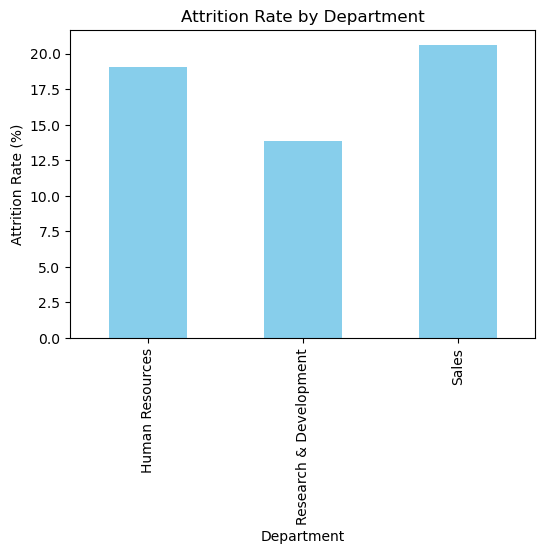


Attrition Rate by Job Role
Attrition                         No        Yes
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


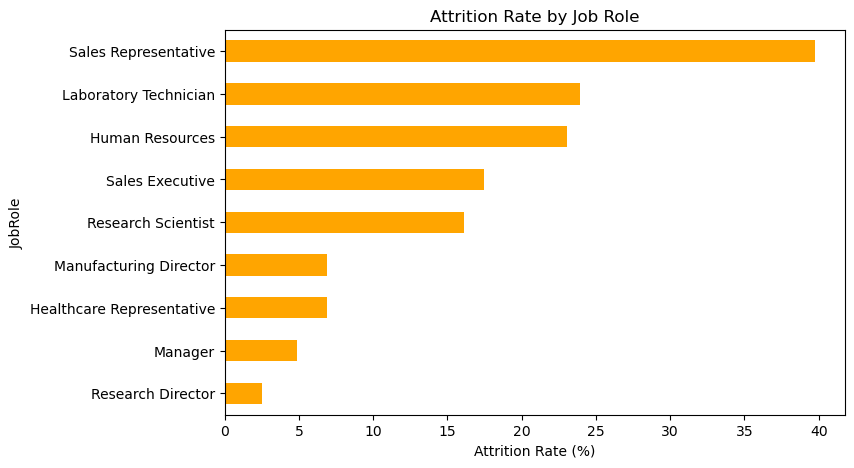

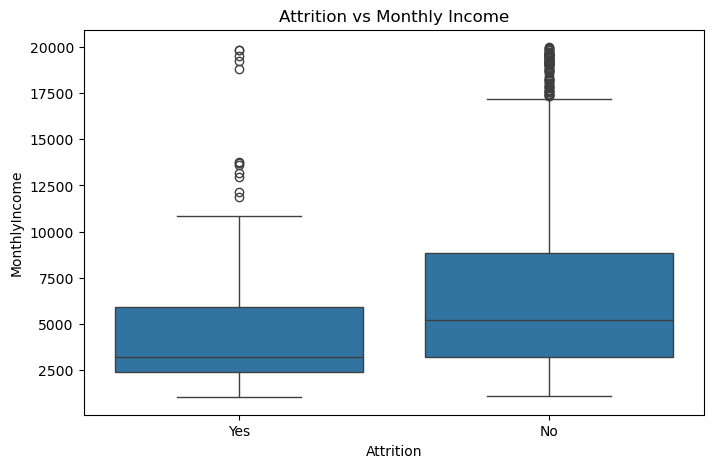


Attrition by Work-Life Balance
Attrition               No        Yes
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059


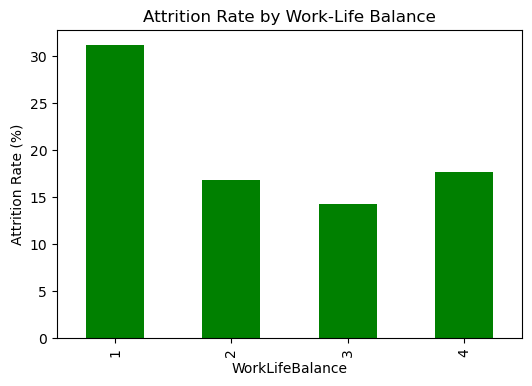

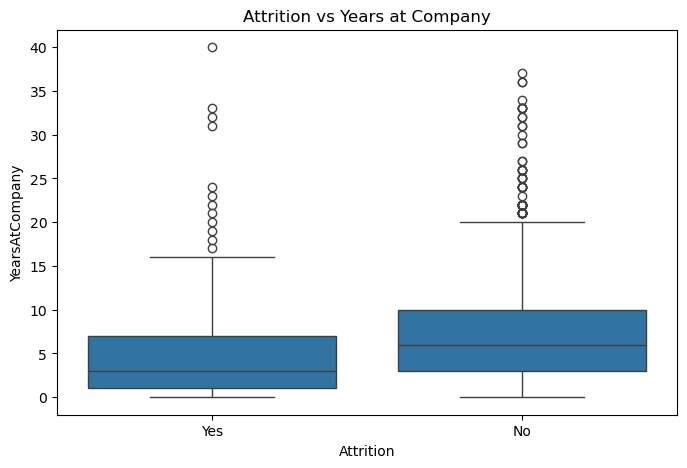

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the original dataset
eda_df = pd.read_csv("HR_Attrition.csv")

# -------------------------------
# 1. Attrition Rate by Department
# -------------------------------

department_attrition = pd.crosstab(
    eda_df["Department"],
    eda_df["Attrition"],
    normalize="index"
) * 100

print("Attrition Rate by Department")
print(department_attrition)

department_attrition["Yes"].plot(kind="bar", color="skyblue", figsize=(6,4))
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.show()


# -------------------------------
# 2. Attrition Rate by Job Role
# -------------------------------

jobrole_attrition = pd.crosstab(
    eda_df["JobRole"],
    eda_df["Attrition"],
    normalize="index"
) * 100

print("\nAttrition Rate by Job Role")
print(jobrole_attrition)

jobrole_attrition["Yes"].sort_values().plot(
    kind="barh",
    color="orange",
    figsize=(8,5)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.show()


# -------------------------------
# 3. Attrition vs Monthly Income
# -------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df
)

plt.title("Attrition vs Monthly Income")
plt.show()


# -------------------------------
# 4. Attrition vs Work-Life Balance
# -------------------------------

worklife = pd.crosstab(
    eda_df["WorkLifeBalance"],
    eda_df["Attrition"],
    normalize="index"
) * 100

print("\nAttrition by Work-Life Balance")
print(worklife)

worklife["Yes"].plot(
    kind="bar",
    color="green",
    figsize=(6,4)
)

plt.title("Attrition Rate by Work-Life Balance")
plt.ylabel("Attrition Rate (%)")
plt.show()


# -------------------------------
# 5. Attrition vs Years at Company
# -------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=eda_df
)

plt.title("Attrition vs Years at Company")
plt.show()

In [ ]:
#  Business Insights

# 1. The **Sales department** has the highest attrition rate (**20.63%**), 
# while **Research & Development** has the lowest (**13.84%**).

# 2. **Sales Representatives** have the highest attrition rate (**39.76%**), 
# whereas **Research Directors** have the lowest (**2.50%**).

# 3. Employees with a **Work-Life Balance rating of 1** have the highest attrition (**31.25%**), 
# showing that poor work-life balance is linked to higher employee turnover.

# 4. Employees who leave the company generally have **lower monthly incomes** than those who stay,
#  indicating that salary may influence attrition.

# 5. Most employees leave during their **early years at the company**, 
# suggesting that retention efforts should focus on new employees.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# Create comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

print("Model Comparison")
display(comparison)

Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394
1,Random Forest,0.833333,0.375000,0.063830,0.109091
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500



Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



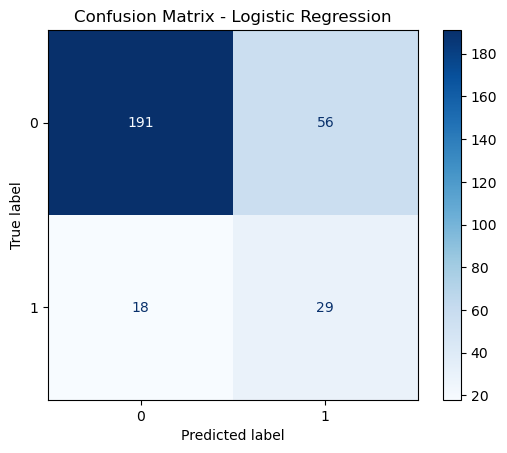


Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294



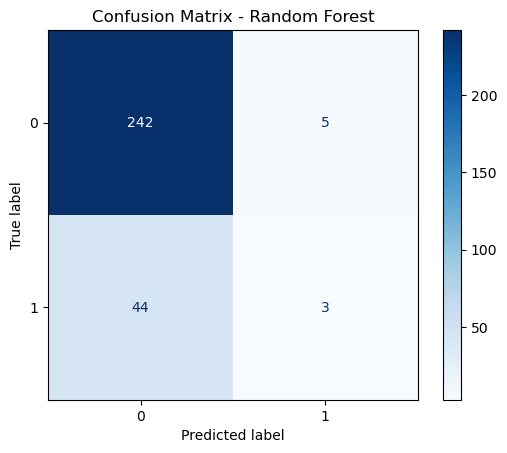


Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



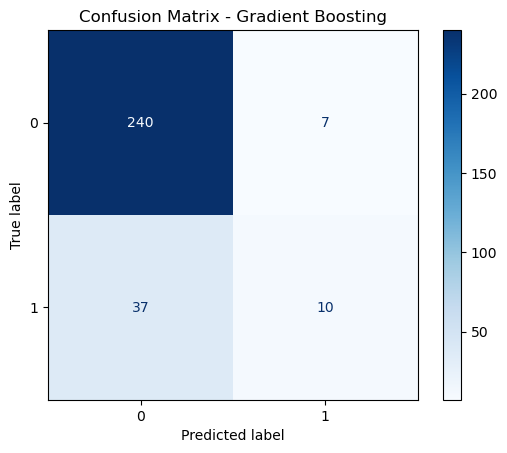


Model Evaluation Summary


,Model,Precision,Recall,F1-Score,ROC-AUC Score
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.375000,0.063830,0.109091,0.751917
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


Best Model: Logistic Regression

Top 10 Important Features


,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


In [6]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
import matplotlib.pyplot as plt
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

predictions = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

results = []

for name, model in models.items():

    y_pred = predictions[name]
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]
    recall = classification_report(y_test, y_pred, output_dict=True)["1"]["recall"]
    f1 = classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"]
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([name, precision, recall, f1, roc_auc])

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred)
    ).plot(cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

evaluation = pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall", "F1-Score", "ROC-AUC Score"]
)

print("\nModel Evaluation Summary")
display(evaluation)

# Best model based on ROC-AUC Score
best_model_name = evaluation.loc[
    evaluation["ROC-AUC Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

# Feature Importance for the Best Model
if best_model_name == "Random Forest":
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    })

elif best_model_name == "Gradient Boosting":
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": gb.feature_importances_
    })

else:
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": abs(lr.coef_[0])
    })

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")
display(feature_importance.head(10))

In [ ]:
# The Logistic Regression model performed the best because it achieved the 
# highest ROC-AUC score (0.799) and the highest Recall (61.70%) among all three models. 
# Since the goal is to identify employees who are likely to leave, a higher 
# recall is important because it correctly identifies more employees at risk of attrition.
# TOP 10 FEATURES
# | Rank | Feature                          | Importance |
# | ---- | -------------------------------- | ---------: |
# | 1    | JobRole_Laboratory Technician    |     0.7979 |
# | 2    | OverTime_Yes                     |     0.7664 |
# | 3    | BusinessTravel_Travel_Frequently |     0.7193 |
# | 4    | JobLevel                         |     0.6592 |
# | 5    | TotalWorkingYears                |     0.6569 |
# | 6    | JobRole_Sales Representative     |     0.5525 |
# | 7    | BusinessTravel_Travel_Rarely     |     0.5116 |
# | 8    | EducationField_Life Sciences     |     0.5065 |
# | 9    | YearsSinceLastPromotion          |     0.5004 |
# | 10   | Department_Sales                 |     0.4817 |


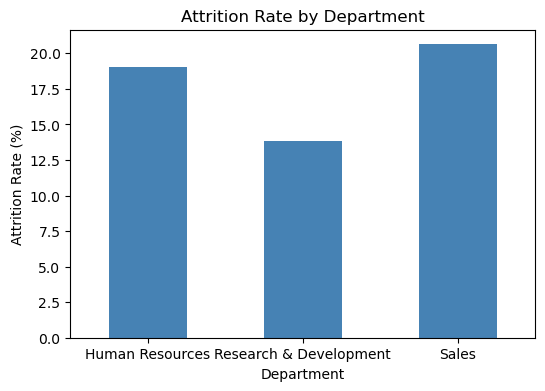

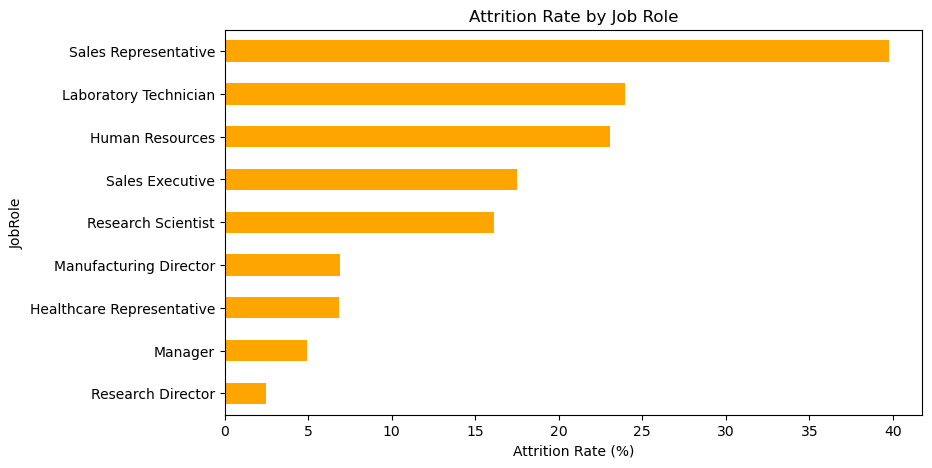

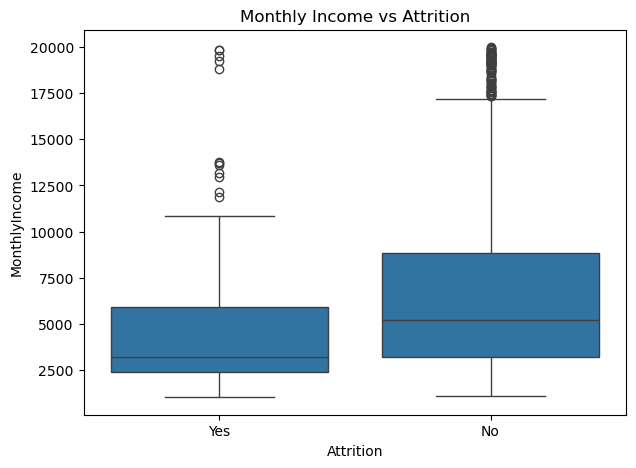

<Figure size 500x400 with 0 Axes>

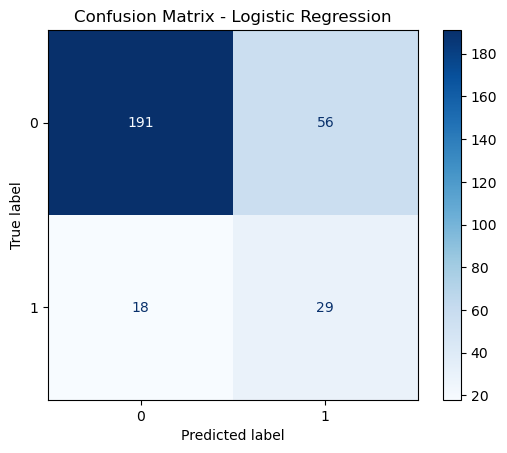

C:\Users\shridula\AppData\Local\Temp\ipykernel_12560\920123606.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


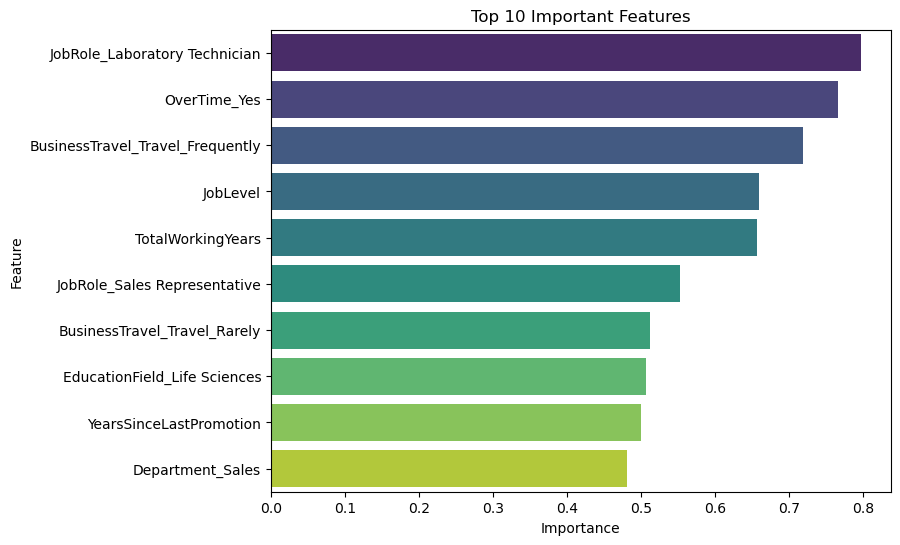

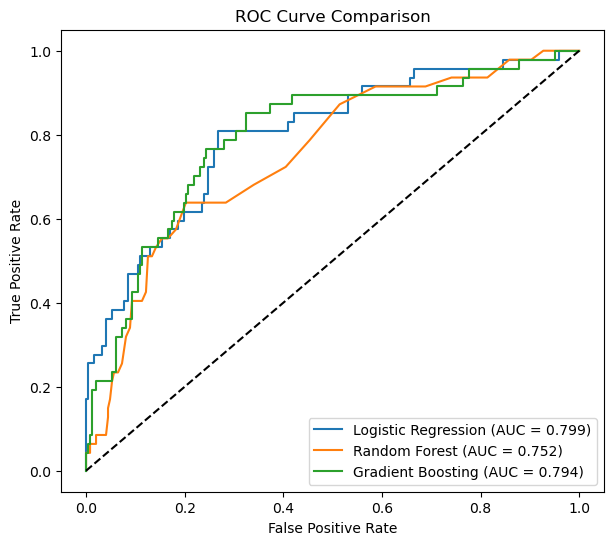

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# -------------------------------
# Chart 1: Attrition Rate by Department
# -------------------------------

plt.figure(figsize=(6,4))

dept_attrition = pd.crosstab(
    eda_df["Department"],
    eda_df["Attrition"],
    normalize="index"
)["Yes"] * 100

dept_attrition.plot(kind="bar", color="steelblue")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()


# -------------------------------
# Chart 1 (Part B): Attrition Rate by Job Role
# -------------------------------

plt.figure(figsize=(9,5))

job_attrition = pd.crosstab(
    eda_df["JobRole"],
    eda_df["Attrition"],
    normalize="index"
)["Yes"] * 100

job_attrition.sort_values().plot(kind="barh", color="orange")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.show()


# -------------------------------
# Chart 2: Monthly Income vs Attrition
# -------------------------------

plt.figure(figsize=(7,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df
)

plt.title("Monthly Income vs Attrition")
plt.show()


# -------------------------------
# Chart 3: Confusion Matrix (Best Model)
# -------------------------------

plt.figure(figsize=(5,4))

ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# -------------------------------
# Chart 4: Top 10 Feature Importances
# -------------------------------

plt.figure(figsize=(8,6))

top10 = feature_importance.head(10)

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10,
    palette="viridis"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# -------------------------------
# Chart 5 (Bonus): ROC Curve
# -------------------------------

plt.figure(figsize=(7,6))

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [ ]:
# The analysis shows that the three strongest factors influencing employee attrition
# are working as a Laboratory Technician, working overtime, and frequent business travel. 

# The Sales department, especially Sales Representatives, should be the primary focus for 
# retention efforts because they have the highest attrition rate (39.76%). 

# Although employees with lower monthly incomes are more likely to leave,
#  salary alone does not explain attrition. Factors such as overtime, job role, business travel,
#  and work-life balance have a greater impact on employee turnover.
 
#  To reduce attrition, the company should improve work-life balance by limiting excessive overtime 
#  and introduce career development and retention programs for high-risk job roles such as 
#  Sales Representatives and Laboratory Technicians. 
 
#  One limitation of this model is that it relies only on historical employee data and 
#  does not account for personal, organizational, or external factors that may influence 
#  an employee's decision to leave.
